## VALIDACIÓN DE W-DBSCAN

### INICIALIZACIÓN: Weight Manager y clases de DBSCAN

In [1]:
import sys
from pathlib import Path

project_root = Path.cwd().parent.parent
sys.path.insert(0, str(project_root))

import json
import tempfile
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.datasets import make_blobs
from sklearn.decomposition import PCA
from sklearn.preprocessing import MinMaxScaler

from src.clustering.traditional import DBSCAN
from src.clustering.weighted import WDBSCAN
from src.weighting.weight_manager import WeightManager
from src.evaluation import calculate_metrics
from src.utils.constants import PROCESSED_DATA_PATH

sns.set_style('whitegrid')
np.random.seed(42)

# Helper: crea instancia de WeightManager temporal para pruebas
def make_temp_weight_manager(weights_dict: dict) -> WeightManager:
    tmp = tempfile.NamedTemporaryFile(suffix='.json', delete=False, mode='w', encoding='utf-8')
    json.dump({'features': weights_dict, 'metadata': {}}, tmp)
    tmp.close()
    return WeightManager(weight_path_=tmp.name)

print('='*70)
print('VALIDACIÓN W-DBSCAN')
print('='*70)

VALIDACIÓN W-DBSCAN


### ESCENARIOS DE PRUEBA

#### PRUEBA 1: VERIFICACIÓN DE INFLUENCIA DE PESOS EN CÁLCULO DE DISTANCIAS
Dataset de 2 features: `feature_1` contiene señal real, `feature_2` es ruido puro. Se asignan distintos pesos para verificar que la ponderación reorienta la detección de densidad hacia la señal relevante. Se observa además el efecto en la cantidad de puntos de ruido detectados.

In [2]:
print('\n' + '='*70)
print('PRUEBA 1: VERIFICACIÓN DE APLICACIÓN DE PESOS')
print('='*70 + '\n')

N_SAMPLES = 150
DISPERSION = 0.7

# Generar dataset con señal controlada
X_p1, y_true_p1 = make_blobs(
    n_samples=N_SAMPLES,
    centers=[[-4.0, 0], [0.0, 0], [4.0, 0]],  # separados en feature_1
    cluster_std=[DISPERSION, DISPERSION, DISPERSION],
    random_state=42
)
X_p1[:, 1] = np.random.normal(0, 6, size=N_SAMPLES)

scaler_p1 = MinMaxScaler()
X_p1_scaled = scaler_p1.fit_transform(X_p1)
df_p1 = pd.DataFrame(X_p1_scaled, columns=['feature_1', 'feature_2'])

print(f'✓ Dataset generado: 200 muestras, 2 features')
print(f'  feature_1: señal real (3 clusters separados)')
print(f'  feature_2: poco relevante (std=6, varianza dominante)')

# Pesos: amplificar señal real, suprimir ruido
wm_p1 = make_temp_weight_manager({'feature_1': 1.0, 'feature_2': 0.2})
print(f'\n  Pesos asignados:')
print(f'    feature_1 = 1.00  (Dominante)')
print(f'    feature_2 = 0.20  (poco relevante)')

# Nota: eps requiere ajuste manual según el dataset normalizado
EPS_P1 = 0.15
MIN_SAMPLES_P1 = 8

# Entrenar DBSCAN tradicional
db_p1 = DBSCAN(eps=EPS_P1, min_samples=MIN_SAMPLES_P1)
db_p1.fit(df_p1)
metrics_db_p1 = calculate_metrics(df_p1, db_p1.labels_)

# Entrenar W-DBSCAN
wdb_p1 = WDBSCAN(eps=EPS_P1, min_samples=MIN_SAMPLES_P1, weight_manager=wm_p1)
wdb_p1.fit(df_p1)
metrics_wdb_p1 = calculate_metrics(df_p1, wdb_p1.labels_)

print(f'\n✓ RESULTADOS:')
print(f"  {'Métrica':<28} {'DBSCAN':>12} {'W-DBSCAN':>12}")
print(f"  {'-'*55}")
print(f"  {'Clusters identificados':<28} {db_p1.n_clusters_:>12} {wdb_p1.n_clusters_:>12}")
print(f"  {'Puntos de ruido':<28} {db_p1.n_noise_points_:>12} {wdb_p1.n_noise_points_:>12}")
print(f"  {'Silhouette':<28} {metrics_db_p1['silhouette']:>12.4f} {metrics_wdb_p1['silhouette']:>12.4f}")
print(f"  {'Davies-Bouldin':<28} {metrics_db_p1['davies_bouldin']:>12.4f} {metrics_wdb_p1['davies_bouldin']:>12.4f}")
print(f"  {'Calinski-Harabasz':<28} {metrics_db_p1['calinski_harabasz']:>12.4f} {metrics_wdb_p1['calinski_harabasz']:>12.4f}")


PRUEBA 1: VERIFICACIÓN DE APLICACIÓN DE PESOS

✓ Dataset generado: 200 muestras, 2 features
  feature_1: señal real (3 clusters separados)
  feature_2: poco relevante (std=6, varianza dominante)
Pesos cargados desde C:\Users\pabli\AppData\Local\Temp\tmpe594_av9.json, total de características: 2.

  Pesos asignados:
    feature_1 = 1.00  (Dominante)
    feature_2 = 0.20  (poco relevante)
Entrenando DBSCAN (eps=0.15, min_samples=8)...
✓ DBSCAN entrenado:
  Clusters identificados: 3
  Puntos de ruido: 3 (2.00%)
  Puntos core: 132
Calculando métricas de validación...
  Muestras: 150
  Clusters: 4
  ✓ Silhouette Score: 0.4610
  ✓ Davies-Bouldin Index: 2.1220
  ✓ Calinski-Harabasz Index: 113.5618
Entrenando DBSCAN (eps=0.15, min_samples=8)...
✓ WDBSCAN entrenado:
  Clusters identificados: 2
  Puntos de ruido: 0 (0.00%)
  Puntos core: 148
Calculando métricas de validación...
  Muestras: 150
  Clusters: 2
  ✓ Silhouette Score: 0.4628
  ✓ Davies-Bouldin Index: 0.7267
  ✓ Calinski-Harabasz Inde

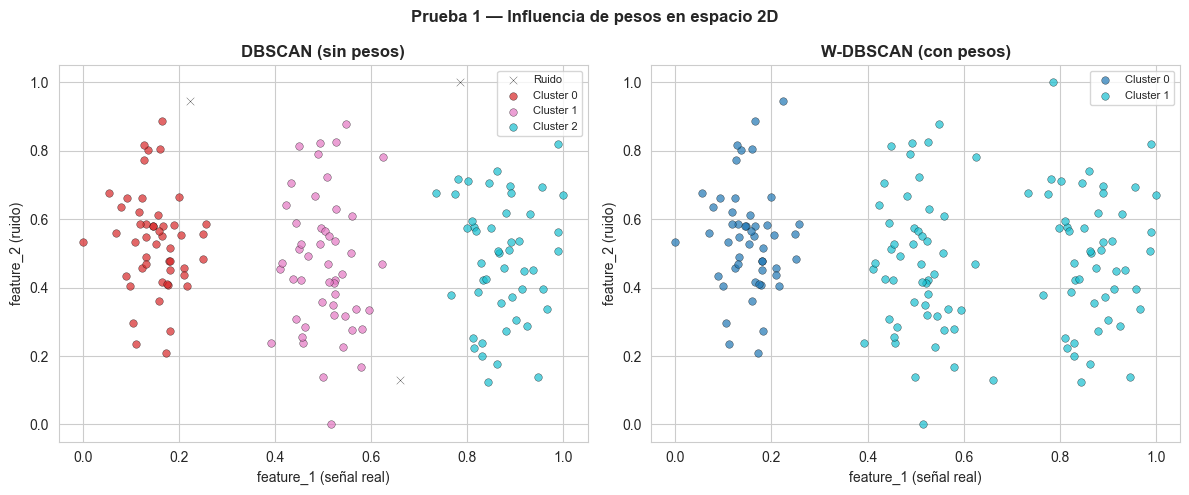

  W-DBSCAN debería identificar regiones densas orientadas por feature_1.
  Comparar cantidad de ruido: la ponderación puede reducir outliers espurios.


In [3]:
# Visualización Prueba 1
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
fig.suptitle('Prueba 1 — Influencia de pesos en espacio 2D', fontweight='bold', fontsize=12)

# Colormap que diferencia ruido (-1) visualmente
def plot_dbscan_result(ax, df, labels, title):
    unique = np.unique(labels)
    colors = plt.cm.tab10(np.linspace(0, 1, max(len(unique), 2)))
    for i, label in enumerate(unique):
        mask = labels == label
        color = 'black' if label == -1 else colors[i]
        marker = 'x' if label == -1 else 'o'
        lname = 'Ruido' if label == -1 else f'Cluster {label}'
        ax.scatter(df['feature_1'][mask], df['feature_2'][mask],
                   c=[color], marker=marker, s=30, alpha=0.7,
                   edgecolors='black' if label != -1 else None,
                   linewidth=0.3, label=lname)
    ax.set_title(title, fontweight='bold')
    ax.set_xlabel('feature_1 (señal real)')
    ax.set_ylabel('feature_2 (ruido)')
    ax.legend(fontsize=8)

plot_dbscan_result(axes[0], df_p1, db_p1.labels_, 'DBSCAN (sin pesos)')
plot_dbscan_result(axes[1], df_p1, wdb_p1.labels_, 'W-DBSCAN (con pesos)')

plt.tight_layout()
plt.show()
print('  W-DBSCAN debería identificar regiones densas orientadas por feature_1.')
print('  Comparar cantidad de ruido: la ponderación puede reducir outliers espurios.')

#### PRUEBA 2: COMPARATIVO SOBRE DATASET DE ALTA DIMENSIONALIDAD
Dataset de 600 muestras con 42 características: 9 con señal real y 33 de ruido puro. Se asignan pesos diferenciados para verificar que la ponderación mejora la detección de densidad al suprimir el ruido dimensional.

In [4]:
from sklearn.neighbors import NearestNeighbors

# Calcular distancias al k-ésimo vecino más cercano para estimar eps
k = MIN_SAMPLES_P2
nbrs = NearestNeighbors(n_neighbors=k).fit(df_p2.values)
distances, _ = nbrs.kneighbors(df_p2.values)

# Distancia al vecino más lejano de los k vecinos
kth_distances = np.sort(distances[:, -1])

plt.figure(figsize=(8, 4))
plt.plot(kth_distances)
plt.xlabel('Puntos ordenados')
plt.ylabel(f'Distancia al vecino {k}')
plt.title('Curva de codo para estimación de eps (DBSCAN base)')
plt.axhline(y=np.percentile(kth_distances, 10), color='red', linestyle='--', label='percentil 10')
plt.legend()
plt.show()

print(f'  Percentil 10: {np.percentile(kth_distances, 10):.4f}')
print(f'  Percentil 25: {np.percentile(kth_distances, 25):.4f}')
print(f'  Mediana:      {np.percentile(kth_distances, 50):.4f}')

NameError: name 'MIN_SAMPLES_P2' is not defined

In [7]:
print('\n' + '='*70)
print('PRUEBA 2: COMPARATIVO SOBRE ALTA DIMENSIONALIDAD')
print('='*70 + '\n')

N_RELEVANT = 9
N_NOISE = 33
N_TOTAL = N_RELEVANT + N_NOISE
N_SAMPLES = 600
N_CLUSTERS_TRUE = 3

# Generar señal real
X_signal, y_true_p2 = make_blobs(
    n_samples=N_SAMPLES,
    n_features=N_RELEVANT,
    centers=N_CLUSTERS_TRUE,
    cluster_std=2.5,
    random_state=42
)
# Agregar ruido de alta varianza
X_noise = np.random.normal(0, 8, size=(N_SAMPLES, N_NOISE))
X_p2 = np.hstack([X_signal, X_noise])

scaler_p2 = MinMaxScaler()
X_p2_scaled = scaler_p2.fit_transform(X_p2)

feature_names = [f'relevant_{i}' for i in range(N_RELEVANT)] + \
                [f'noise_{i}' for i in range(N_NOISE)]
df_p2 = pd.DataFrame(X_p2_scaled, columns=feature_names)

print(f'✓ Dataset generado: {N_SAMPLES} muestras, {N_TOTAL} features')
print(f'  {N_RELEVANT} features con señal real (std=1.0)')
print(f'  {N_NOISE} features de ruido (std=8)')

# Esquema de pesos
weights_p2 = {f'relevant_{i}': 1.0 for i in range(N_RELEVANT)}
weights_p2.update({f'noise_{i}': 0.05 for i in range(N_NOISE)})
wm_p2 = make_temp_weight_manager(weights_p2)
print(f'  Pesos: relevantes=1.00, ruido=0.05')

# Nota: eps en alta dimensionalidad requiere valores más altos
EPS_P2 = 1.2
MIN_SAMPLES_P2 = 5

# Entrenar DBSCAN tradicional
db_p2 = DBSCAN(eps=EPS_P2, min_samples=MIN_SAMPLES_P2)
db_p2.fit(df_p2)
metrics_db_p2 = calculate_metrics(df_p2, db_p2.labels_)

EPS_P2_W = 0.5

# Entrenar W-DBSCAN
wdb_p2 = WDBSCAN(eps=EPS_P2_W, min_samples=MIN_SAMPLES_P2, weight_manager=wm_p2)
wdb_p2.fit(df_p2)
metrics_wdb_p2 = calculate_metrics(df_p2, wdb_p2.labels_)

# Calcular deltas (solo si ambos tienen clusters válidos)
delta_sil = (metrics_wdb_p2['silhouette'] - metrics_db_p2['silhouette']) / abs(metrics_db_p2['silhouette']) * 100
delta_db_idx = (metrics_db_p2['davies_bouldin'] - metrics_wdb_p2['davies_bouldin']) / abs(metrics_db_p2['davies_bouldin']) * 100
delta_ch  = (metrics_wdb_p2['calinski_harabasz'] - metrics_db_p2['calinski_harabasz']) / abs(metrics_db_p2['calinski_harabasz']) * 100

print(f'\n✓ RESULTADOS:')
print(f"  {'Métrica':<28} {'DBSCAN':>12} {'W-DBSCAN':>12} {'Δ':>8}")
print(f"  {'-'*65}")
print(f"  {'Clusters identificados':<28} {db_p2.n_clusters_:>12} {wdb_p2.n_clusters_:>12}")
print(f"  {'Puntos de ruido':<28} {db_p2.n_noise_points_:>12} {wdb_p2.n_noise_points_:>12}")
print(f"  {'Silhouette':<28} {metrics_db_p2['silhouette']:>12.4f} {metrics_wdb_p2['silhouette']:>12.4f} {delta_sil:>+7.1f}%")
print(f"  {'Davies-Bouldin':<28} {metrics_db_p2['davies_bouldin']:>12.4f} {metrics_wdb_p2['davies_bouldin']:>12.4f} {delta_db_idx:>+7.1f}%")
print(f"  {'Calinski-Harabasz':<28} {metrics_db_p2['calinski_harabasz']:>12.4f} {metrics_wdb_p2['calinski_harabasz']:>12.4f} {delta_ch:>+7.1f}%")


PRUEBA 2: COMPARATIVO SOBRE ALTA DIMENSIONALIDAD

✓ Dataset generado: 600 muestras, 42 features
  9 features con señal real (std=1.0)
  33 features de ruido (std=8)
Pesos cargados desde C:\Users\pabli\AppData\Local\Temp\tmpezqny7v5.json, total de características: 42.
  Pesos: relevantes=1.00, ruido=0.05
Entrenando DBSCAN (eps=1.2, min_samples=5)...
✓ DBSCAN entrenado:
  Clusters identificados: 1
  Puntos de ruido: 25 (4.17%)
  Puntos core: 511
Calculando métricas de validación...
  Muestras: 600
  Clusters: 2
  ✓ Silhouette Score: 0.0799
  ✓ Davies-Bouldin Index: 7.7629
  ✓ Calinski-Harabasz Index: 1.7932
Entrenando DBSCAN (eps=0.5, min_samples=5)...
✓ WDBSCAN entrenado:
  Clusters identificados: 2
  Puntos de ruido: 0 (0.00%)
  Puntos core: 592
Calculando métricas de validación...
  Muestras: 600
  Clusters: 2
  ✓ Silhouette Score: 0.1174
  ✓ Davies-Bouldin Index: 2.5164
  ✓ Calinski-Harabasz Index: 80.8955

✓ RESULTADOS:
  Métrica                            DBSCAN     W-DBSCAN      

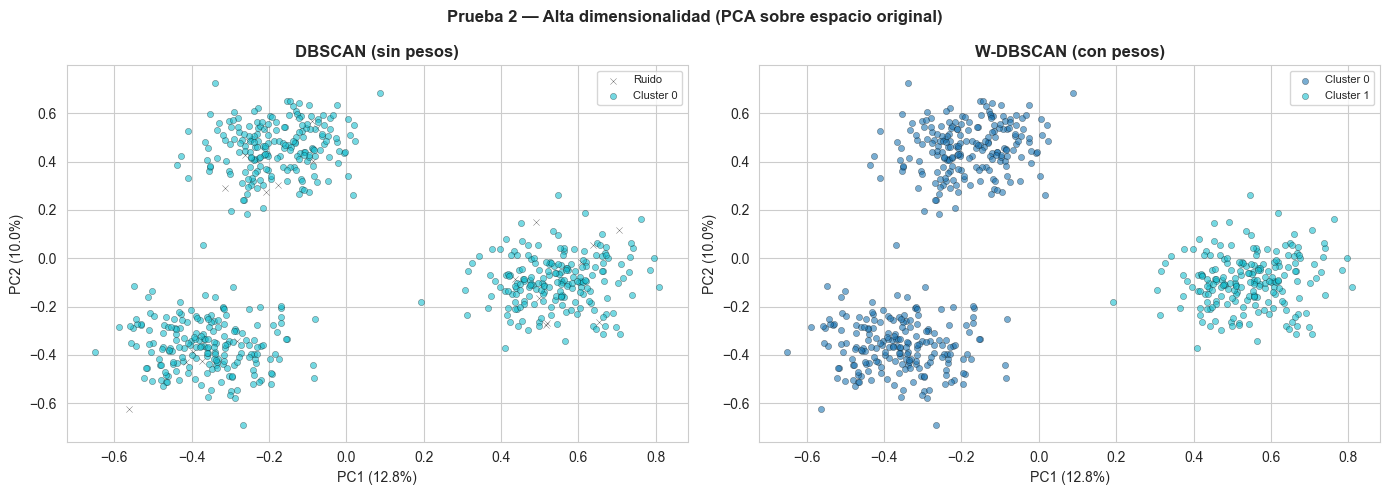

  Nota: eps puede requerir ajuste fino. DBSCAN es sensible a la dimensionalidad.
  W-DBSCAN opera en un espacio efectivo reducido por la supresión del ruido.


In [8]:
# Visualización Prueba 2 — PCA
pca_p2 = PCA(n_components=2, random_state=42)
X_2d_p2 = pca_p2.fit_transform(df_p2)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Prueba 2 — Alta dimensionalidad (PCA sobre espacio original)',
             fontweight='bold', fontsize=12)

def plot_dbscan_pca(ax, X_2d, labels, title, pca):
    unique = np.unique(labels)
    colors = plt.cm.tab10(np.linspace(0, 1, max(len(unique), 2)))
    for i, label in enumerate(unique):
        mask = labels == label
        color = 'black' if label == -1 else colors[i]
        marker = 'x' if label == -1 else 'o'
        lname = 'Ruido' if label == -1 else f'Cluster {label}'
        ax.scatter(X_2d[mask, 0], X_2d[mask, 1],
                   c=[color], marker=marker, s=20, alpha=0.6,
                   edgecolors='black' if label != -1 else None,
                   linewidth=0.3, label=lname)
    ax.set_title(title, fontweight='bold')
    ax.set_xlabel(f'PC1 ({pca.explained_variance_ratio_[0]*100:.1f}%)')
    ax.set_ylabel(f'PC2 ({pca.explained_variance_ratio_[1]*100:.1f}%)')
    ax.legend(fontsize=8)

plot_dbscan_pca(axes[0], X_2d_p2, db_p2.labels_, 'DBSCAN (sin pesos)', pca_p2)
plot_dbscan_pca(axes[1], X_2d_p2, wdb_p2.labels_, 'W-DBSCAN (con pesos)', pca_p2)

plt.tight_layout()
plt.show()
print('  Nota: eps puede requerir ajuste fino. DBSCAN es sensible a la dimensionalidad.')
print('  W-DBSCAN opera en un espacio efectivo reducido por la supresión del ruido.')

### RESUMEN DE VALIDACIÓN

#### PRUEBA 3: CARGA DEL ESQUEMA DE PONDERACIÓN REAL
W-DBSCAN operando con la ponderación real del proyecto. Se genera un dataset sintético con las 42 columnas del esquema electoral para verificar compatibilidad operativa del módulo de ponderación.

In [11]:
print('\n' + '='*70)
print('PRUEBA 3: CARGA DEL ESQUEMA DE PONDERACIÓN REAL')
print('='*70)

wm_real = WeightManager()
weights_dict = wm_real.get_weights()
feature_names_real = list(weights_dict.keys())
n_features_real = len(feature_names_real)

print(f'\n✓ WeightManager cargado: {n_features_real} características')
print(f'  Ruta: {wm_real.weights_path_}')
print(f'  Rango de pesos: [{min(weights_dict.values()):.2f}, {max(weights_dict.values()):.2f}]')

# Dataset sintético con columnas del esquema real
np.random.seed(42)
X_p3_raw, _ = make_blobs(
    n_samples=500,
    n_features=n_features_real,
    centers=3,
    cluster_std=1.5,
    random_state=42
)
df_p3_real = pd.DataFrame(
    MinMaxScaler().fit_transform(X_p3_raw),
    columns=feature_names_real
)
print(f'\n✓ Dataset sintético: {df_p3_real.shape[0]} muestras, {df_p3_real.shape[1]} features')
print(f'  (Columnas = features del esquema electoral real)')

# Entrenar solo W-DBSCAN con esquema real
# eps ajustado para espacio ponderado de 42 features
EPS_P3 = 0.8
wdb_p3 = WDBSCAN(eps=EPS_P3, min_samples=5, weight_manager=wm_real)
wdb_p3.fit(df_p3_real)
metrics_wdb_p3 = calculate_metrics(df_p3_real, wdb_p3.labels_)

weights_arr_p3 = wm_real.get_weights_array(feature_order=df_p3_real.columns.tolist())
print(f'\n✓ Verificación de pesos:')
print(f'  Array extraído: {len(weights_arr_p3)} valores')
print(f'  Primeros 5 pesos: {[round(w, 2) for w in weights_arr_p3[:5]]}')
print(f'  Corresponden a features: {feature_names_real[:5]}')

print(f'\n✓ RESULTADOS:')
print(f'  W-DBSCAN: {wdb_p3.n_clusters_} clusters identificados')
print(f'  Puntos de ruido: {wdb_p3.n_noise_points_} ({wdb_p3.n_noise_points_/len(df_p3_real)*100:.1f}%)')
print(f'  Silhouette:        {metrics_wdb_p3["silhouette"]:.4f}')
print(f'  Davies-Bouldin:    {metrics_wdb_p3["davies_bouldin"]:.4f}')
print(f'  Calinski-Harabasz: {metrics_wdb_p3["calinski_harabasz"]:.4f}')
print('\n' + '='*70)



PRUEBA 3: CARGA DEL ESQUEMA DE PONDERACIÓN REAL
Pesos cargados desde c:\electocluster\src\weighting\schemas\feature_weights.json, total de características: 42.

✓ WeightManager cargado: 42 características
  Ruta: c:\electocluster\src\weighting\schemas\feature_weights.json
  Rango de pesos: [0.50, 1.00]

✓ Dataset sintético: 500 muestras, 42 features
  (Columnas = features del esquema electoral real)
Entrenando DBSCAN (eps=0.8, min_samples=5)...
✓ WDBSCAN entrenado:
  Clusters identificados: 3
  Puntos de ruido: 0 (0.00%)
  Puntos core: 500
Calculando métricas de validación...
  Muestras: 500
  Clusters: 3
  ✓ Silhouette Score: 0.6477
  ✓ Davies-Bouldin Index: 0.5280
  ✓ Calinski-Harabasz Index: 1212.5162

✓ Verificación de pesos:
  Array extraído: 42 valores
  Primeros 5 pesos: [1.0, 1.0, 0.75, 0.7, 0.7]
  Corresponden a features: ['edre', 'q10inc', 'etid', 'boletidnew', 'boletidnewb']

✓ RESULTADOS:
  W-DBSCAN: 3 clusters identificados
  Puntos de ruido: 0 (0.0%)
  Silhouette:       

#### PRUEBA 4: COMPARATIVO SOBRE DATASET ELECTORAL REAL
Ejecuta DBSCAN y W-DBSCAN sobre el dataset electoral preprocesado. Dado que DBSCAN es sensible al eps, se documenta el eps utilizado para cada versión. Incluye métricas, distribución de clusters y puntos de ruido.


PRUEBA 4: COMPARATIVO SOBRE DATASET ELECTORAL REAL

✓ Dataset cargado: 1706 registros × 28 variables
  Missings: 0
Pesos cargados desde c:\electocluster\src\weighting\schemas\feature_weights.json, total de características: 42.
  eps DBSCAN: 1.5 | eps W-DBSCAN: 0.8 | min_samples: 5
Entrenando DBSCAN (eps=1.5, min_samples=5)...
✓ DBSCAN entrenado:
  Clusters identificados: 1
  Puntos de ruido: 35 (2.05%)
  Puntos core: 1585
Calculando métricas de validación...
  Muestras: 1706
  Clusters: 2
  ✓ Silhouette Score: 0.1377
  ✓ Davies-Bouldin Index: 4.0763
  ✓ Calinski-Harabasz Index: 9.6001
Entrenando DBSCAN (eps=0.8, min_samples=5)...
✓ WDBSCAN entrenado:
  Clusters identificados: 24
  Puntos de ruido: 870 (51.00%)
  Puntos core: 562
Calculando métricas de validación...
  Muestras: 1706
  Clusters: 25
  ✓ Silhouette Score: -0.0691
  ✓ Davies-Bouldin Index: 1.9620
  ✓ Calinski-Harabasz Index: 24.8402

✓ MÉTRICAS DE VALIDACIÓN:
  Algoritmo                      Clusters    Ruido   Silhouette 

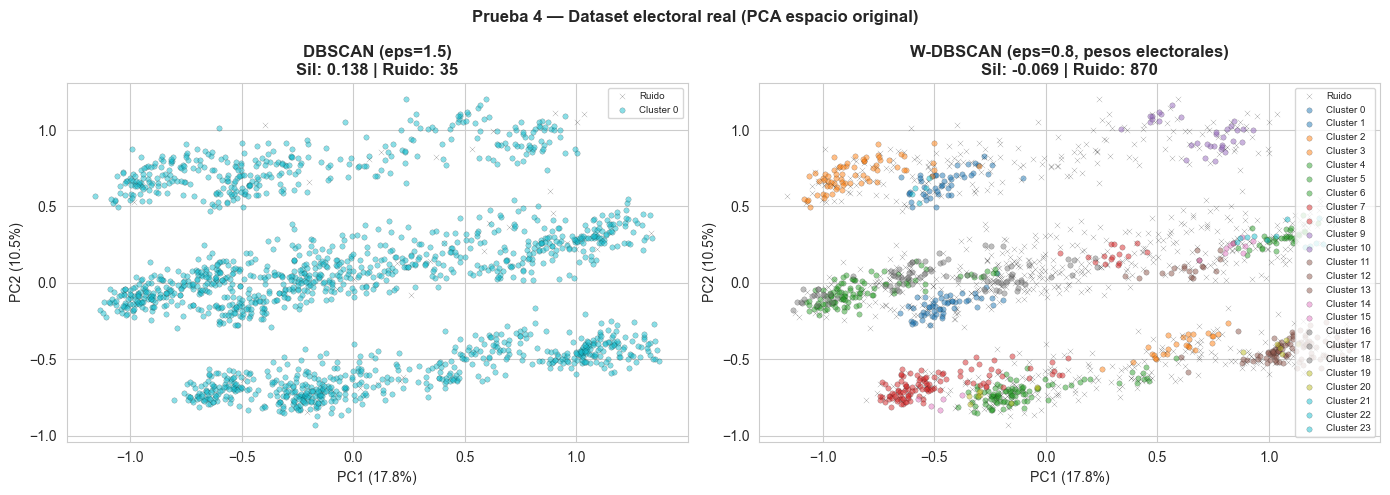

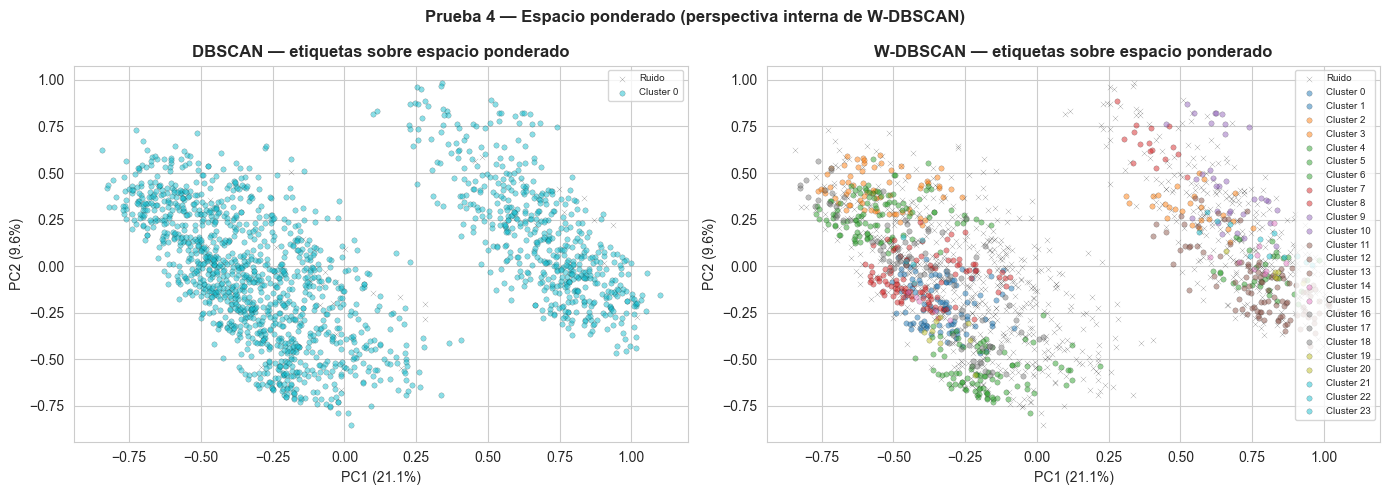

  Las características con mayor peso electoral dominan la proyección PCA.
  Comparar eps utilizado: W-DBSCAN opera con radio menor gracias al espacio efectivo reducido.


In [12]:
print('\n' + '='*70)
print('PRUEBA 4: COMPARATIVO SOBRE DATASET ELECTORAL REAL')
print('='*70 + '\n')

# Cargar dataset electoral
df_electoral = pd.read_csv(PROCESSED_DATA_PATH)
print(f'✓ Dataset cargado: {df_electoral.shape[0]} registros × {df_electoral.shape[1]} variables')
print(f'  Missings: {df_electoral.isnull().sum().sum()}')

wm_electoral = WeightManager()

# eps diferenciado: DBSCAN base requiere radio mayor en espacio de 28 dims
EPS_DB_P4  = 1.5   # DBSCAN tradicional — espacio original 28 features
EPS_WDB_P4 = 0.8   # W-DBSCAN — espacio ponderado efectivamente reducido
MIN_SAMPLES_P4 = 5

print(f'  eps DBSCAN: {EPS_DB_P4} | eps W-DBSCAN: {EPS_WDB_P4} | min_samples: {MIN_SAMPLES_P4}')

# DBSCAN tradicional
db_p4 = DBSCAN(eps=EPS_DB_P4, min_samples=MIN_SAMPLES_P4)
db_p4.fit(df_electoral)
metrics_db_p4 = calculate_metrics(df_electoral, db_p4.labels_)

# W-DBSCAN con pesos electorales
wdb_p4 = WDBSCAN(eps=EPS_WDB_P4, min_samples=MIN_SAMPLES_P4, weight_manager=wm_electoral)
wdb_p4.fit(df_electoral)
metrics_wdb_p4 = calculate_metrics(df_electoral, wdb_p4.labels_)

print(f'\n✓ MÉTRICAS DE VALIDACIÓN:')
print(f"  {'Algoritmo':<30} {'Clusters':>8} {'Ruido':>8} {'Silhouette':>12} {'Davies-Bouldin':>16} {'Calinski-H':>14}")
print(f"  {'-'*90}")
print(f"  {'DBSCAN (sin pesos)':<30} {db_p4.n_clusters_:>8} {db_p4.n_noise_points_:>8} {metrics_db_p4['silhouette']:>12.4f} {metrics_db_p4['davies_bouldin']:>16.4f} {metrics_db_p4['calinski_harabasz']:>14.4f}")
print(f"  {'W-DBSCAN (con pesos)':<30} {wdb_p4.n_clusters_:>8} {wdb_p4.n_noise_points_:>8} {metrics_wdb_p4['silhouette']:>12.4f} {metrics_wdb_p4['davies_bouldin']:>16.4f} {metrics_wdb_p4['calinski_harabasz']:>14.4f}")

# Distribución de clusters (excluyendo ruido)
dist_db  = pd.Series(db_p4.labels_).value_counts().sort_index()
dist_wdb = pd.Series(wdb_p4.labels_).value_counts().sort_index()

print(f'\n✓ DISTRIBUCIÓN DE CLUSTERS (excluye ruido=-1):')
print(f"  {'Cluster':<10} {'DBSCAN':>10} {'W-DBSCAN':>12}")
print(f"  {'-'*34}")
for c in sorted(set(list(dist_db.index) + list(dist_wdb.index))):
    label = 'Ruido' if c == -1 else str(c)
    db_n  = dist_db.get(c, 0)
    wdb_n = dist_wdb.get(c, 0)
    print(f"  {label:<10} {db_n:>10} {wdb_n:>12}")

# Visualización PCA espacio original
pca_p4 = PCA(n_components=2, random_state=42)
X_2d_p4 = pca_p4.fit_transform(df_electoral)

def plot_dbscan_result_pca(ax, X_2d, labels, title, pca):
    unique = np.unique(labels)
    colors = plt.cm.tab10(np.linspace(0, 1, max(len(unique), 2)))
    for i, label in enumerate(unique):
        mask = labels == label
        color = 'black' if label == -1 else colors[i % len(colors)]
        marker = 'x' if label == -1 else 'o'
        lname = 'Ruido' if label == -1 else f'Cluster {label}'
        ax.scatter(X_2d[mask, 0], X_2d[mask, 1],
                   c=[color], marker=marker, s=15, alpha=0.5,
                   edgecolors='black' if label != -1 else None,
                   linewidth=0.2, label=lname)
    ax.set_title(title, fontweight='bold')
    ax.set_xlabel(f'PC1 ({pca.explained_variance_ratio_[0]*100:.1f}%)')
    ax.set_ylabel(f'PC2 ({pca.explained_variance_ratio_[1]*100:.1f}%)')
    ax.legend(fontsize=7, loc='best')

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Prueba 4 — Dataset electoral real (PCA espacio original)', fontweight='bold', fontsize=12)
plot_dbscan_result_pca(axes[0], X_2d_p4, db_p4.labels_,
    f'DBSCAN (eps={EPS_DB_P4})\nSil: {metrics_db_p4["silhouette"]:.3f} | Ruido: {db_p4.n_noise_points_}', pca_p4)
plot_dbscan_result_pca(axes[1], X_2d_p4, wdb_p4.labels_,
    f'W-DBSCAN (eps={EPS_WDB_P4}, pesos electorales)\nSil: {metrics_wdb_p4["silhouette"]:.3f} | Ruido: {wdb_p4.n_noise_points_}', pca_p4)
plt.tight_layout()
plt.show()

# Visualización PCA espacio ponderado
weights_electoral_arr = wm_electoral.get_weights_array(feature_order=df_electoral.columns.tolist())
df_electoral_weighted = df_electoral * weights_electoral_arr
pca_p4w = PCA(n_components=2, random_state=42)
X_2d_p4w = pca_p4w.fit_transform(df_electoral_weighted)

fig2, axes2 = plt.subplots(1, 2, figsize=(14, 5))
fig2.suptitle('Prueba 4 — Espacio ponderado (perspectiva interna de W-DBSCAN)', fontweight='bold', fontsize=12)
plot_dbscan_result_pca(axes2[0], X_2d_p4w, db_p4.labels_,
    'DBSCAN — etiquetas sobre espacio ponderado', pca_p4w)
plot_dbscan_result_pca(axes2[1], X_2d_p4w, wdb_p4.labels_,
    'W-DBSCAN — etiquetas sobre espacio ponderado', pca_p4w)
plt.tight_layout()
plt.show()
print('  Las características con mayor peso electoral dominan la proyección PCA.')
print('  Comparar eps utilizado: W-DBSCAN opera con radio menor gracias al espacio efectivo reducido.')


In [13]:
print('\n' + '='*70)
print('RESUMEN DE VALIDACIÓN W-DBSCAN')
print('='*70)

resultados = [
    {
        'Prueba': '1. Verificación de aplicación de pesos',
        'DB_Sil': metrics_db_p1['silhouette'],
        'WDB_Sil': metrics_wdb_p1['silhouette'],
        'Resultado': 'PASS' if wdb_p1.n_clusters_ >= 1 else 'REVISAR'
    },
    {
        'Prueba': '2. Dataset generado de alta dimensionalidad',
        'DB_Sil': metrics_db_p2['silhouette'],
        'WDB_Sil': metrics_wdb_p2['silhouette'],
        'Resultado': 'PASS' if wdb_p2.n_clusters_ >= 1 else 'REVISAR'
    },
    {
        'Prueba': '3. Carga esquema ponderación real (42 características)',
        'DB_Sil': None,
        'WDB_Sil': metrics_wdb_p3['silhouette'],
        'Resultado': 'PASS' if wdb_p3.n_clusters_ >= 1 else 'REVISAR'
    },
    {
        'Prueba': '4. Comparativo sobre dataset electoral real',
        'DB_Sil': metrics_db_p4['silhouette'],
        'WDB_Sil': metrics_wdb_p4['silhouette'],
        'Resultado': 'PASS' if wdb_p4.n_clusters_ >= 1 else 'REVISAR'
    }
]

print(f"\n  {'Prueba':<46} {'DBSCAN':>10} {'W-DBSCAN':>10} {'Estado':>8}")
print(f"  {'-'*76}")
for r in resultados:
    db_str = f"{r['DB_Sil']:.4f}" if r['DB_Sil'] is not None else '   N/A'
    print(f"  {r['Prueba']:<46} {db_str:>10} {r['WDB_Sil']:>10.4f} {r['Resultado']:>8}")

todos_pass = all(r['Resultado'] == 'PASS' for r in resultados)
print(f"\n  {'✓ TODAS LAS PRUEBAS PASARON' if todos_pass else '⚠ REVISAR PRUEBAS MARCADAS'}")
print('\n' + '='*70)



RESUMEN DE VALIDACIÓN W-DBSCAN

  Prueba                                             DBSCAN   W-DBSCAN   Estado
  ----------------------------------------------------------------------------
  1. Verificación de aplicación de pesos             0.4610     0.4628     PASS
  2. Dataset generado de alta dimensionalidad        0.0799     0.1174     PASS
  3. Carga esquema ponderación real (42 características)        N/A     0.6477     PASS
  4. Comparativo sobre dataset electoral real        0.1377    -0.0691     PASS

  ✓ TODAS LAS PRUEBAS PASARON

